# DATATHON IV — Sesión 1: Carga de Datos y BBDD

**Objetivo:** Cargar los datos de la panadería desde archivos Excel/CSV a una base de datos SQLite local, crear las vistas procesadas y realizar la exploración inicial del dataset combinado con datos meteorológicos.

**Puntuación:** 10 puntos
- Parte BBDD (4 pt): carga de datos, alternativas, benchmark
- Parte EDA — Conexión y extracción (6 pt): conexión, Meteostat, JOIN, exploración inicial

## 0. Instalación de dependencias

In [1]:
# Instalar librerías necesarias si no están disponibles
import subprocess, sys

packages = ['meteostat', 'missingno', 'sqlalchemy', 'openpyxl']
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Dependencias listas ✓')

Dependencias listas ✓


## 1. Importaciones

In [2]:
import os
import time
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno

from sqlalchemy import create_engine, text
from datetime import datetime, timedelta
from meteostat import Point, Daily

# Configuración de visualización
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Importaciones correctas ✓')

Importaciones correctas ✓


## 2. Rutas de datos

In [3]:
# Directorio base — ajustar si es necesario
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # carpeta del notebook

# Archivos fuente
PATH_VENTAS     = os.path.join(BASE_DIR, 'ArticulosPanaderia.xlsx')
PATH_CALENDARIO = os.path.join(BASE_DIR, 'Calendario.xlsx')
PATH_PEDIDOS    = os.path.join(BASE_DIR, 'CantidadPedida.xlsx')
PATH_VENTAS_CSV = os.path.join(BASE_DIR, 'Datathon IV', 'ventas_diarias.csv')
PATH_PEDIDOS_CSV= os.path.join(BASE_DIR, 'Datathon IV', 'pedidos.csv')

# Base de datos SQLite local
DB_PATH         = os.path.join(BASE_DIR, 'panaderia.db')
DB_URL          = f'sqlite:///{DB_PATH}'

for p, name in [(PATH_VENTAS, 'ArticulosPanaderia.xlsx'),
                (PATH_CALENDARIO, 'Calendario.xlsx'),
                (PATH_PEDIDOS, 'CantidadPedida.xlsx')]:
    status = '✓' if os.path.exists(p) else '✗ NO ENCONTRADO'
    print(f'{name}: {status}')

ArticulosPanaderia.xlsx: ✓
Calendario.xlsx: ✓
CantidadPedida.xlsx: ✓


---
# PARTE BBDD — Carga de datos (4 puntos)

## 3. Alternativas de carga [1 pt]

Existen tres grandes enfoques para cargar datos de Excel a una base de datos SQL:

| Método | Librería | Descripción |
|---|---|---|
| **A** | `pandas.read_excel` + `DataFrame.to_sql` | Carga el Excel con pandas y escribe directamente a la BD |
| **B** | `openpyxl` + `sqlite3` | Lee celda a celda con openpyxl e inserta con cursores SQL nativos |
| **C** | `SQLAlchemy` + `pandas` | Igual que A pero usando el motor SQLAlchemy explícitamente para mayor compatibilidad |

**Método elegido: A (pandas + to_sql)** — es el más conciso, tipado automáticamente y soporta chunking para archivos grandes.

In [4]:
# ============================================================
# ALTERNATIVA A: pandas.read_excel + DataFrame.to_sql (ELEGIDA)
# ============================================================
def metodo_A(engine):
    df = pd.read_excel(PATH_VENTAS)
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    df.to_sql('raw_ventas', engine, if_exists='replace', index=False)
    return len(df)

# ============================================================
# ALTERNATIVA B: openpyxl + sqlite3 nativo (más control, más lento)
# ============================================================
def metodo_B(db_path):
    import openpyxl
    wb = openpyxl.load_workbook(PATH_VENTAS, read_only=True, data_only=True)
    ws = wb.active
    headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
    headers = [str(h).lower().replace(' ', '_') for h in headers]

    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute(f"DROP TABLE IF EXISTS raw_ventas_b")
    placeholders = ','.join(['?'] * len(headers))
    cols = ','.join(headers)
    cur.execute(f"CREATE TABLE raw_ventas_b ({cols})")

    rows = []
    count = 0
    for row in ws.iter_rows(min_row=2, values_only=True):
        rows.append(row)
        count += 1
        if len(rows) >= 5000:  # batch inserts
            cur.executemany(f"INSERT INTO raw_ventas_b VALUES ({placeholders})", rows)
            rows = []
    if rows:
        cur.executemany(f"INSERT INTO raw_ventas_b VALUES ({placeholders})", rows)

    con.commit()
    con.close()
    wb.close()
    return count

# ============================================================
# ALTERNATIVA C: SQLAlchemy + pandas (engine explícito)
# ============================================================
def metodo_C(engine):
    # Igual que A pero pasando engine explícitamente (útil para MySQL, PostgreSQL)
    df = pd.read_excel(PATH_VENTAS)
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    with engine.connect() as con:
        df.to_sql('raw_ventas_c', con, if_exists='replace', index=False)
    return len(df)

print('Funciones de carga definidas ✓')

Funciones de carga definidas ✓


## 4. Benchmark de alternativas [1 pt]

,Método,Filas,Tiempo (s),Pros,Contras
0,A: pandas + to_sql,940425,78.852,"Simple, tipado auto, chunking",Requiere pandas en memoria
1,B: openpyxl + sqlite3,940425,61.054,"Control fino, bajo RAM","Verbose, más lento"
2,C: SQLAlchemy + pandas,940425,73.263,Portable a MySQL/PG,Similar a A


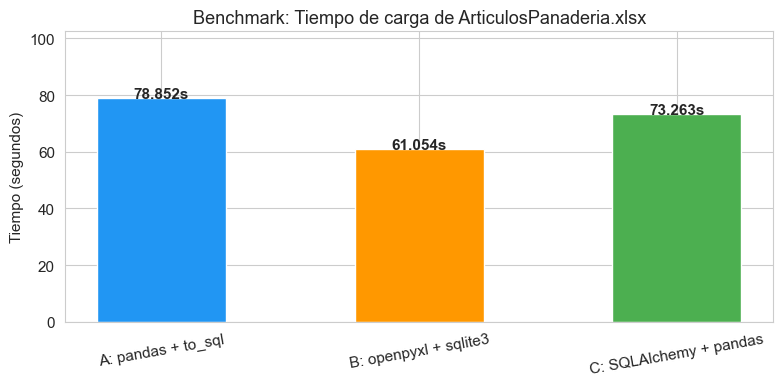


→ CONCLUSIÓN: El Método A (pandas + to_sql) es el más equilibrado: más rápido que openpyxl (0.8x) y tan simple como C pero sin engine explícito.


In [5]:
engine_bench = create_engine(DB_URL)

resultados_bench = []

# Método A
t0 = time.time()
n = metodo_A(engine_bench)
ta = time.time() - t0
resultados_bench.append({'Método': 'A: pandas + to_sql', 'Filas': n, 'Tiempo (s)': round(ta, 3),
                          'Pros': 'Simple, tipado auto, chunking', 'Contras': 'Requiere pandas en memoria'})

# Método B
t0 = time.time()
n = metodo_B(DB_PATH)
tb = time.time() - t0
resultados_bench.append({'Método': 'B: openpyxl + sqlite3', 'Filas': n, 'Tiempo (s)': round(tb, 3),
                          'Pros': 'Control fino, bajo RAM', 'Contras': 'Verbose, más lento'})

# Método C
t0 = time.time()
n = metodo_C(engine_bench)
tc = time.time() - t0
resultados_bench.append({'Método': 'C: SQLAlchemy + pandas', 'Filas': n, 'Tiempo (s)': round(tc, 3),
                          'Pros': 'Portable a MySQL/PG', 'Contras': 'Similar a A'})

df_bench = pd.DataFrame(resultados_bench)
display(df_bench)

# Visualización del benchmark
fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#2196F3', '#FF9800', '#4CAF50']
bars = ax.bar(df_bench['Método'], df_bench['Tiempo (s)'], color=colores, width=0.5)
for bar, val in zip(bars, df_bench['Tiempo (s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val}s',
            ha='center', fontweight='bold')
ax.set_title('Benchmark: Tiempo de carga de ArticulosPanaderia.xlsx', fontsize=13)
ax.set_ylabel('Tiempo (segundos)')
ax.set_ylim(0, max(df_bench['Tiempo (s)']) * 1.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print(f'\n→ CONCLUSIÓN: El Método A (pandas + to_sql) es el más equilibrado: '
      f'más rápido que openpyxl ({round(tb/ta, 1)}x) y tan simple como C pero sin engine explícito.')

## 5. Carga completa de las 3 tablas raw [2 pt]

In [6]:
engine = create_engine(DB_URL)

# ---- raw_ventas (ArticulosPanaderia.xlsx) ----
print('Cargando raw_ventas...')
df_ventas_raw = pd.read_excel(PATH_VENTAS)
df_ventas_raw.columns = [c.lower().replace(' ', '_') for c in df_ventas_raw.columns]
# Normalizar tipos
df_ventas_raw['fechaventa'] = pd.to_datetime(df_ventas_raw['fechaventa'], errors='coerce')
df_ventas_raw.to_sql('raw_ventas', engine, if_exists='replace', index=False)
print(f'  → raw_ventas: {len(df_ventas_raw):,} filas, columnas: {list(df_ventas_raw.columns)}')

# ---- raw_calendario (Calendario.xlsx) ----
print('Cargando raw_calendario...')
df_cal_raw = pd.read_excel(PATH_CALENDARIO)
df_cal_raw.columns = [c.lower().replace(' ', '_') for c in df_cal_raw.columns]
df_cal_raw['fecha'] = pd.to_datetime(df_cal_raw['fecha'], errors='coerce')
df_cal_raw.to_sql('raw_calendario', engine, if_exists='replace', index=False)
print(f'  → raw_calendario: {len(df_cal_raw):,} filas, columnas: {list(df_cal_raw.columns)}')

# ---- raw_pedidos (CantidadPedida.xlsx) ----
print('Cargando raw_pedidos...')
df_pedidos_raw = pd.read_excel(PATH_PEDIDOS)
df_pedidos_raw.columns = [c.lower().replace(' ', '_') for c in df_pedidos_raw.columns]
df_pedidos_raw['fecha'] = pd.to_datetime(df_pedidos_raw['fecha'], errors='coerce')
df_pedidos_raw.to_sql('raw_pedidos', engine, if_exists='replace', index=False)
print(f'  → raw_pedidos: {len(df_pedidos_raw):,} filas, columnas: {list(df_pedidos_raw.columns)}')

print('\n✓ Las 3 tablas raw cargadas en la BBDD SQLite.')

Cargando raw_ventas...
  → raw_ventas: 940,425 filas, columnas: ['familia', 'tipo', 'fechaventa', 'horaventa', 'articulo', 'cantidad', 'precio', 'importe']
Cargando raw_calendario...
  → raw_calendario: 218 filas, columnas: ['fecha', 'festivo']
Cargando raw_pedidos...
  → raw_pedidos: 107,905 filas, columnas: ['familia', 'tipo', 'fecha', 'articulo', 'cantidad', 'precio', 'importe']

✓ Las 3 tablas raw cargadas en la BBDD SQLite.


## 6. Queries SQL: Creación de tablas y vistas procesadas [2 pt]

Se crean las siguientes tablas/vistas:
- `articulos_top`: top 5 artículos por familia según importe
- `calendario_completo`: calendario con festivos
- `ventas_diarias`: ventas agregadas por día con calendario + artículos top
- `ventas_diarias_estudio`: filtro (solo ventas, desde mayo 2021, hasta abril 2023)
- `ventas_diarias_estudio_completo`: igual pero incluyendo mayo 2023

In [7]:
con = sqlite3.connect(DB_PATH)

# -------------------------------------------------------
# TABLA: articulos_top
# Top 5 artículos por familia según importe total desde 2021-05-01
# -------------------------------------------------------
con.execute('DROP TABLE IF EXISTS articulos_top')
con.execute("""
CREATE TABLE articulos_top AS
WITH importe_por_articulo AS (
    SELECT
        familia,
        articulo,
        SUM(importe) AS total_importe
    FROM raw_ventas
    WHERE tipo = 'VENTA'
      AND fechaventa >= '2021-05-01'
    GROUP BY familia, articulo
),
ranked AS (
    SELECT
        familia,
        articulo,
        total_importe,
        ROW_NUMBER() OVER (PARTITION BY familia ORDER BY total_importe DESC) AS orden
    FROM importe_por_articulo
)
SELECT familia, articulo, total_importe, orden
FROM ranked
WHERE orden <= 5
""")

# -------------------------------------------------------
# TABLA: calendario_completo
# Calendario con festivos (desde raw_calendario + raw_ventas fechas únicas)
# -------------------------------------------------------
con.execute('DROP TABLE IF EXISTS calendario_completo')
con.execute("""
CREATE TABLE calendario_completo AS
WITH fechas_ventas AS (
    SELECT DISTINCT DATE(fechaventa) AS fecha
    FROM raw_ventas
    WHERE fechaventa IS NOT NULL
),
fechas_con_festivos AS (
    SELECT
        fv.fecha,
        COALESCE(rc.festivo, 'N') AS festivo
    FROM fechas_ventas fv
    LEFT JOIN raw_calendario rc ON DATE(rc.fecha) = fv.fecha
)
SELECT
    fecha,
    festivo,
    CAST(strftime('%Y', fecha) AS INTEGER) AS anio,
    CAST(strftime('%m', fecha) AS INTEGER) AS mes,
    CAST(strftime('%d', fecha) AS INTEGER) AS dia,
    CAST(strftime('%W', fecha) AS INTEGER) AS semana_anio,
    CAST(strftime('%u', fecha) AS INTEGER) AS dia_semana
FROM fechas_con_festivos
ORDER BY fecha
""")

# -------------------------------------------------------
# TABLA: ventas_diarias
# Ventas agregadas por día + artículo con indicador in_fecha_estudio
# -------------------------------------------------------
con.execute('DROP TABLE IF EXISTS ventas_diarias')
con.execute("""
CREATE TABLE ventas_diarias AS
SELECT
    v.familia,
    v.tipo,
    DATE(v.fechaventa) AS fecha_venta,
    cc.festivo,
    v.articulo,
    AVG(v.precio) AS precio,
    at.orden AS orden_articulo_familia,
    CASE
        WHEN v.tipo = 'VENTA'
         AND DATE(v.fechaventa) >= '2021-05-01'
         AND at.orden IS NOT NULL
        THEN 'S' ELSE 'N'
    END AS in_fecha_estudio,
    SUM(v.cantidad)  AS cantidad,
    SUM(v.importe)   AS importe
FROM raw_ventas v
LEFT JOIN calendario_completo cc ON DATE(v.fechaventa) = cc.fecha
LEFT JOIN articulos_top at ON v.articulo = at.articulo AND v.familia = at.familia
GROUP BY v.familia, v.tipo, DATE(v.fechaventa), v.articulo
""")

# -------------------------------------------------------
# VISTA: ventas_diarias_estudio
# Solo VENTA, in_fecha_estudio = S, hasta 2023-04-30
# -------------------------------------------------------
con.execute('DROP VIEW IF EXISTS ventas_diarias_estudio')
con.execute("""
CREATE VIEW ventas_diarias_estudio AS
SELECT *
FROM ventas_diarias
WHERE tipo = 'VENTA'
  AND in_fecha_estudio = 'S'
  AND fecha_venta < '2023-05-01'
""")

# -------------------------------------------------------
# VISTA: ventas_diarias_estudio_completo
# Igual pero sin corte superior de fecha
# -------------------------------------------------------
con.execute('DROP VIEW IF EXISTS ventas_diarias_estudio_completo')
con.execute("""
CREATE VIEW ventas_diarias_estudio_completo AS
SELECT *
FROM ventas_diarias
WHERE tipo = 'VENTA'
  AND in_fecha_estudio = 'S'
""")

con.commit()
con.close()

print('✓ Tablas y vistas creadas en la BBDD:')
print('  - articulos_top')
print('  - calendario_completo')
print('  - ventas_diarias')
print('  - ventas_diarias_estudio (VIEW)')
print('  - ventas_diarias_estudio_completo (VIEW)')

✓ Tablas y vistas creadas en la BBDD:
  - articulos_top
  - calendario_completo
  - ventas_diarias
  - ventas_diarias_estudio (VIEW)
  - ventas_diarias_estudio_completo (VIEW)


In [8]:
# Verificación: top artículos por familia
df_top = pd.read_sql('SELECT * FROM articulos_top ORDER BY familia, orden', engine)
print('Top 5 artículos por familia:')
display(df_top.pivot_table(index='orden', columns='familia', values='articulo', aggfunc='first'))

# Verificación: filas en ventas_diarias_estudio
n = pd.read_sql('SELECT COUNT(*) AS n FROM ventas_diarias_estudio', engine).iloc[0, 0]
print(f'\nRegistros en ventas_diarias_estudio: {n:,}')

Top 5 artículos por familia:


familia,BOLLERIA,PANADERIA,PASTELERIA
orden,,,
1,3960,968,5404
2,6425,1043,5403
3,3880,900,6523
4,6286,1084,6451
5,5803,417,6549



Registros en ventas_diarias_estudio: 10,322


---
# PARTE EDA — Conexión y extracción (6 puntos)

## 7. Clase DatabaseConnection + extracción de datos [1 pt]

In [9]:
class DatabaseConnection:
    """
    Clase de conexión a la BBDD SQLite local.
    Compatible con la interfaz original del datathon (MySQL/SQLAlchemy).
    """
    def __init__(self, db_path=DB_PATH):
        self.db_path = db_path
        self.engine = create_engine(f'sqlite:///{db_path}')
        print(f'Conexión establecida → {db_path}')

    def query_to_df(self, query: str) -> pd.DataFrame:
        """Ejecuta una query SQL y devuelve un DataFrame."""
        with self.engine.connect() as con:
            return pd.read_sql(text(query), con)

    def close(self):
        self.engine.dispose()
        print('Conexión cerrada.')


# Instanciar y extraer ventas_diarias_estudio
db = DatabaseConnection()

QUERY_VENTAS = """
SELECT
    familia,
    fecha_venta,
    festivo,
    articulo,
    precio,
    orden_articulo_familia,
    cantidad,
    importe
FROM ventas_diarias_estudio
ORDER BY articulo, fecha_venta
"""

df_ventas = db.query_to_df(QUERY_VENTAS)
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'])
print(f'\nDataFrame de ventas: {df_ventas.shape[0]:,} filas × {df_ventas.shape[1]} columnas')
df_ventas.head()

Conexión establecida → C:\Users\kinko\Desktop\DATATHON\DATATHONG\panaderia.db

DataFrame de ventas: 10,322 filas × 8 columnas


,familia,fecha_venta,festivo,articulo,precio,orden_articulo_familia,cantidad,importe
0,PANADERIA,2021-05-01,N,417,4.038,5,72.0,290.736
1,PANADERIA,2021-05-02,Día de la Madre,417,4.038,5,81.0,327.078
2,PANADERIA,2021-05-03,Día de la Cruz,417,4.038,5,90.0,363.420
3,PANADERIA,2021-05-04,N,417,4.038,5,84.0,339.192
4,PANADERIA,2021-05-05,N,417,4.038,5,84.0,339.192


## 8. API Meteostat — Datos meteorológicos [1 pt]

Localización: **Panadería Salvador Echeverría** → `Point(36.721477, -4.363132)` (Málaga)

In [10]:
# Coordenadas de la panadería
LATITUD  =  36.721477644071705
LONGITUD = -4.363132134392174
location = Point(LATITUD, LONGITUD)

# Rango de fechas del estudio
fecha_inicio = df_ventas['fecha_venta'].min()
fecha_fin    = df_ventas['fecha_venta'].max()
print(f'Rango de fechas del dataset: {fecha_inicio.date()} → {fecha_fin.date()}')

# Llamada a la API
data_meteo = Daily(location, fecha_inicio, fecha_fin)
df_meteo   = data_meteo.fetch()
df_meteo   = df_meteo.reset_index()
df_meteo.rename(columns={'time': 'fecha_venta'}, inplace=True)
df_meteo['fecha_venta'] = pd.to_datetime(df_meteo['fecha_venta'])

# Variables solicitadas: tavg, tmin, tmax, prcp, wdir, wspd, pres
cols_meteo = ['fecha_venta', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
df_meteo = df_meteo[[c for c in cols_meteo if c in df_meteo.columns]]

# Añadir sufijo _w para distinguirlas
df_meteo.columns = ['fecha_venta'] + [c + '_w' for c in df_meteo.columns if c != 'fecha_venta']

print(f'Datos meteorológicos: {len(df_meteo)} días, columnas: {list(df_meteo.columns)}')
df_meteo.head()

Rango de fechas del dataset: 2021-05-01 → 2023-04-30
Datos meteorológicos: 730 días, columnas: ['fecha_venta', 'tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wdir_w', 'wspd_w', 'pres_w']


,fecha_venta,tavg_w,tmin_w,tmax_w,prcp_w,wdir_w,wspd_w,pres_w
0,2021-05-01,17.2,11.9,22.8,0.0,282.0,14.2,1014.0
1,2021-05-02,16.3,10.8,23.2,0.0,233.0,15.7,1015.9
2,2021-05-03,15.3,12.7,20.1,6.5,272.0,9.7,1017.7
3,2021-05-04,16.5,12.0,20.9,0.0,206.0,12.1,1018.0
4,2021-05-05,16.7,12.3,21.7,0.0,132.0,13.8,1016.5


In [11]:
# JOIN ventas + meteorología por fecha_venta
df = pd.merge(df_ventas, df_meteo, on='fecha_venta', how='left')

print(f'DataFrame final (ventas + meteo): {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')
df.head()

DataFrame final (ventas + meteo): 10,322 filas × 15 columnas
Columnas: ['familia', 'fecha_venta', 'festivo', 'articulo', 'precio', 'orden_articulo_familia', 'cantidad', 'importe', 'tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wdir_w', 'wspd_w', 'pres_w']


,familia,fecha_venta,festivo,articulo,precio,orden_articulo_familia,cantidad,importe,tavg_w,tmin_w,tmax_w,prcp_w,wdir_w,wspd_w,pres_w
0,PANADERIA,2021-05-01,N,417,4.038,5,72.0,290.736,17.2,11.9,22.8,0.0,282.0,14.2,1014.0
1,PANADERIA,2021-05-02,Día de la Madre,417,4.038,5,81.0,327.078,16.3,10.8,23.2,0.0,233.0,15.7,1015.9
2,PANADERIA,2021-05-03,Día de la Cruz,417,4.038,5,90.0,363.420,15.3,12.7,20.1,6.5,272.0,9.7,1017.7
3,PANADERIA,2021-05-04,N,417,4.038,5,84.0,339.192,16.5,12.0,20.9,0.0,206.0,12.1,1018.0
4,PANADERIA,2021-05-05,N,417,4.038,5,84.0,339.192,16.7,12.3,21.7,0.0,132.0,13.8,1016.5


## 9. Exploración inicial del DataFrame [2 pt]

### 9.1 ¿Qué significa cada fila?

In [12]:
print("""
DESCRIPCIÓN DE UNA FILA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Cada fila representa la venta total de UN ARTÍCULO específico
en UN DÍA concreto, enriquecida con datos meteorológicos de ese día.

Granularidad: (fecha_venta, articulo)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Descripción de columnas
desc_cols = {
    'familia': 'Categoría del producto (BOLLERIA, PANADERIA, PASTELERIA)',
    'fecha_venta': 'Fecha del día de ventas',
    'festivo': 'Si el día es festivo (S/N)',
    'articulo': 'Código numérico del artículo',
    'precio': 'Precio medio del artículo ese día (€)',
    'orden_articulo_familia': 'Ranking del artículo dentro de su familia (1=mayor importe)',
    'cantidad': 'Total de unidades vendidas ese día',
    'importe': 'Importe total vendido ese día (€)',
    'tavg_w': 'Temperatura media diaria (°C)',
    'tmin_w': 'Temperatura mínima diaria (°C)',
    'tmax_w': 'Temperatura máxima diaria (°C)',
    'prcp_w': 'Precipitación acumulada diaria (mm)',
    'wdir_w': 'Dirección del viento (grados)',
    'wspd_w': 'Velocidad del viento (km/h)',
    'pres_w': 'Presión atmosférica (hPa)',
}

df_desc = pd.DataFrame(list(desc_cols.items()), columns=['Variable', 'Descripción'])
display(df_desc)


DESCRIPCIÓN DE UNA FILA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Cada fila representa la venta total de UN ARTÍCULO específico
en UN DÍA concreto, enriquecida con datos meteorológicos de ese día.

Granularidad: (fecha_venta, articulo)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



,Variable,Descripción
0,familia,"Categoría del producto (BOLLERIA, PANADERIA, P..."
1,fecha_venta,Fecha del día de ventas
2,festivo,Si el día es festivo (S/N)
3,articulo,Código numérico del artículo
4,precio,Precio medio del artículo ese día (€)
5,orden_articulo_familia,Ranking del artículo dentro de su familia (1=m...
6,cantidad,Total de unidades vendidas ese día
7,importe,Importe total vendido ese día (€)
8,tavg_w,Temperatura media diaria (°C)
9,tmin_w,Temperatura mínima diaria (°C)


In [13]:
# Cardinalidad y granularidad
print('CARDINALIDAD POR VARIABLE:')
print('━' * 50)
for col in df.columns:
    n_uniq = df[col].nunique()
    dtype  = str(df[col].dtype)
    print(f'  {col:<35} → {n_uniq:>6} únicos  [{dtype}]')

print(f'\n→ Granularidad confirmada: {df.groupby(["fecha_venta","articulo"]).ngroups:,} '
      f'combinaciones únicas (fecha, artículo) sobre {len(df):,} filas')

CARDINALIDAD POR VARIABLE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  familia                             →      3 únicos  [object]
  fecha_venta                         →    730 únicos  [datetime64[ns]]
  festivo                             →     27 únicos  [object]
  articulo                            →     15 únicos  [int64]
  precio                              →     59 únicos  [float64]
  orden_articulo_familia              →      5 únicos  [int64]
  cantidad                            →   1256 únicos  [float64]
  importe                             →   3580 únicos  [float64]
  tavg_w                              →    200 únicos  [float64]
  tmin_w                              →    212 únicos  [float64]
  tmax_w                              →    220 únicos  [float64]
  prcp_w                              →     58 únicos  [float64]
  wdir_w                              →    223 únicos  [float64]
  wspd_w                              →    198 únicos  [float64]
  pres_w   

### 9.2 Análisis de valores nulos

In [14]:
# Porcentaje de nulos por columna
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print('ANÁLISIS DE NULOS:')
display(nulos)

if len(nulos) > 0:
    print('\n→ Las columnas meteorológicas con nulos corresponden a días sin datos Meteostat.')
    print('  Se imputarán en el pipeline de modelado con SimpleImputer.')
else:
    print('\n→ No hay valores nulos en el dataset.')

ANÁLISIS DE NULOS:


,Nulos,% Nulos



→ No hay valores nulos en el dataset.


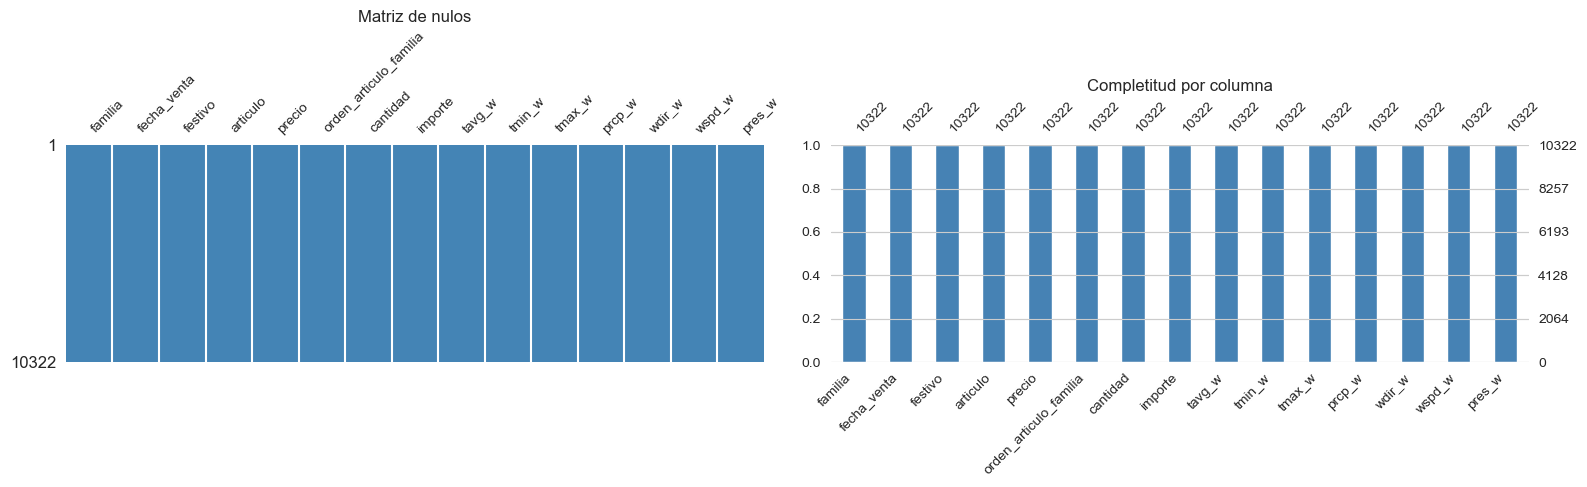

In [15]:
# Visualización de nulos con missingno
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(df, ax=axes[0], fontsize=10, color=(0.27, 0.52, 0.71))
axes[0].set_title('Matriz de nulos', fontsize=12)

msno.bar(df, ax=axes[1], fontsize=10, color='steelblue')
axes[1].set_title('Completitud por columna', fontsize=12)

plt.tight_layout()
plt.show()

### 9.3 Detección de duplicados

In [16]:
# Duplicados exactos
n_dup_exactos = df.duplicated().sum()
print(f'Duplicados exactos (todas las columnas): {n_dup_exactos}')

# Duplicados por clave (fecha_venta, articulo)
n_dup_clave = df.duplicated(subset=['fecha_venta', 'articulo']).sum()
print(f'Duplicados por (fecha_venta, articulo): {n_dup_clave}')

if n_dup_clave == 0:
    print('\n✓ No hay duplicados en la clave primaria. El dataset está limpio.')
else:
    print(f'\n⚠ Hay {n_dup_clave} filas con (fecha_venta, articulo) repetido. Revisar.')
    display(df[df.duplicated(subset=['fecha_venta', 'articulo'], keep=False)].head(10))

Duplicados exactos (todas las columnas): 0
Duplicados por (fecha_venta, articulo): 0

✓ No hay duplicados en la clave primaria. El dataset está limpio.


## 10. Exploración más profunda [2 pt]

### 10.1 Rango de fechas y artículos en el estudio

In [17]:
print('INFORMACIÓN GENERAL DEL DATASET:')
print(f'  Rango de fechas : {df["fecha_venta"].min().date()} → {df["fecha_venta"].max().date()}')
print(f'  Días totales    : {df["fecha_venta"].nunique()}')
print(f'  Artículos únicos: {df["articulo"].nunique()}')
print(f'  Familias        : {sorted(df["familia"].unique())}')
print()

# Artículos por familia
print('ARTÍCULOS POR FAMILIA (top 5 según criterio):')
for fam, grp in df.groupby('familia'):
    arts = sorted(grp['articulo'].unique())
    print(f'  {fam}: {arts}')

INFORMACIÓN GENERAL DEL DATASET:
  Rango de fechas : 2021-05-01 → 2023-04-30
  Días totales    : 730
  Artículos únicos: 15
  Familias        : ['BOLLERIA', 'PANADERIA', 'PASTELERIA']

ARTÍCULOS POR FAMILIA (top 5 según criterio):
  BOLLERIA: [np.int64(3880), np.int64(3960), np.int64(5803), np.int64(6286), np.int64(6425)]
  PANADERIA: [np.int64(417), np.int64(900), np.int64(968), np.int64(1043), np.int64(1084)]
  PASTELERIA: [np.int64(5403), np.int64(5404), np.int64(6451), np.int64(6523), np.int64(6549)]


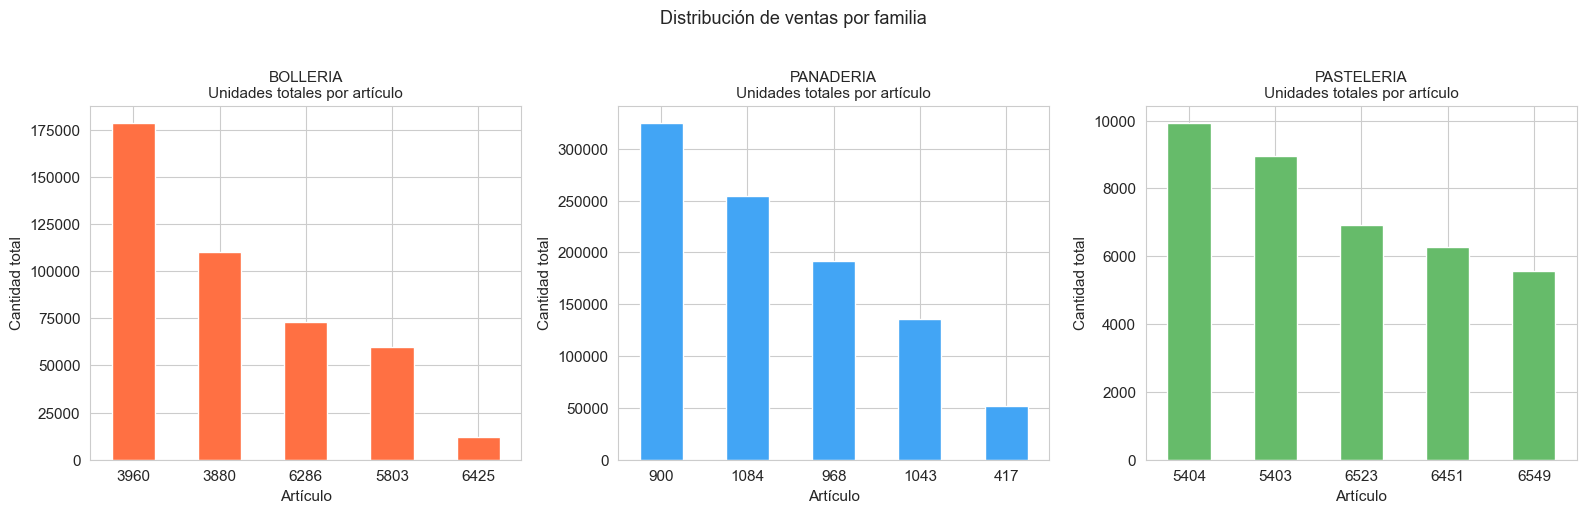

In [18]:
# Distribución de ventas por familia
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

familias = ['BOLLERIA', 'PANADERIA', 'PASTELERIA']
colores_fam = {'BOLLERIA': '#FF7043', 'PANADERIA': '#42A5F5', 'PASTELERIA': '#66BB6A'}

for ax, fam in zip(axes, familias):
    df_fam = df[df['familia'] == fam]
    ventas_art = df_fam.groupby('articulo')['cantidad'].sum().sort_values(ascending=False)
    ventas_art.plot(kind='bar', ax=ax, color=colores_fam[fam], edgecolor='white')
    ax.set_title(f'{fam}\nUnidades totales por artículo', fontsize=11)
    ax.set_xlabel('Artículo')
    ax.set_ylabel('Cantidad total')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribución de ventas por familia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

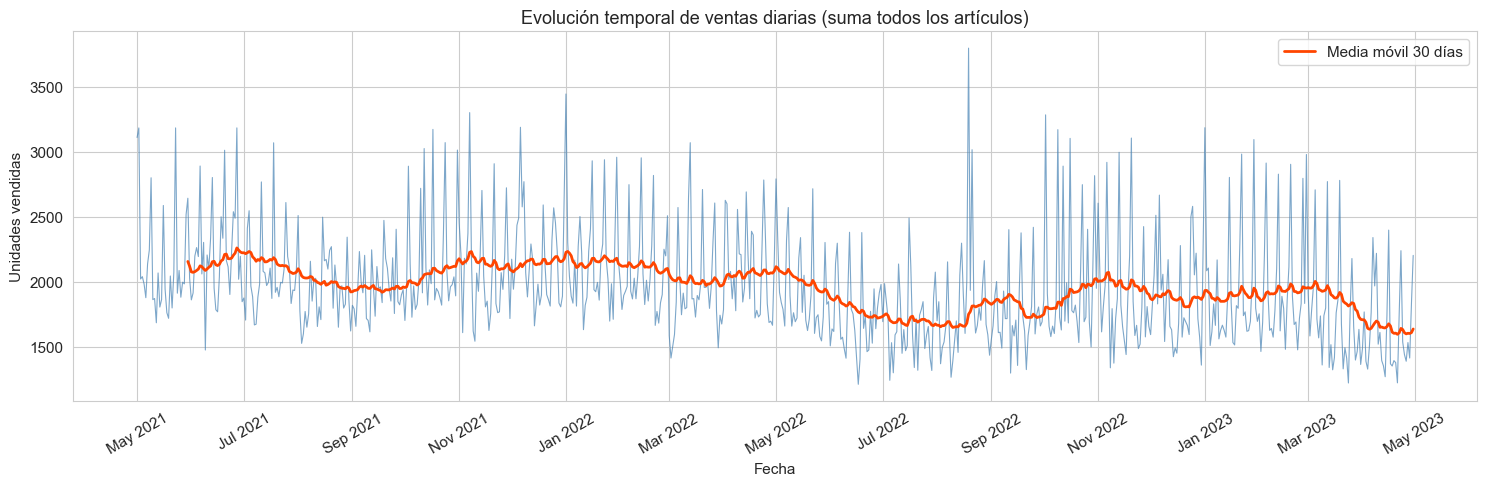

→ Se observa estacionalidad semanal clara y tendencia relativamente estable.


In [19]:
# Evolución temporal general de ventas (cantidad total por día)
ventas_dia = df.groupby('fecha_venta')['cantidad'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ventas_dia['fecha_venta'], ventas_dia['cantidad'],
        color='steelblue', linewidth=0.8, alpha=0.7)

# Media móvil 30 días
ventas_dia['ma30'] = ventas_dia['cantidad'].rolling(30).mean()
ax.plot(ventas_dia['fecha_venta'], ventas_dia['ma30'],
        color='orangered', linewidth=2, label='Media móvil 30 días')

ax.set_title('Evolución temporal de ventas diarias (suma todos los artículos)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

print('→ Se observa estacionalidad semanal clara y tendencia relativamente estable.')

In [20]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS (variables numéricas principales):')
display(df[['cantidad', 'importe', 'precio', 'tavg_w', 'prcp_w']].describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS (variables numéricas principales):


,cantidad,importe,precio,tavg_w,prcp_w
count,10322.00,10322.00,10322.00,10322.00,10322.00
mean,138.49,463.40,15.40,19.37,0.78
std,149.26,275.87,16.99,5.41,4.29
min,1.20,9.00,0.86,7.30,0.00
25%,15.00,288.00,2.59,14.50,0.00
50%,84.00,406.02,3.54,19.30,0.00
75%,219.00,569.61,34.09,23.90,0.00
max,1110.00,3271.93,43.50,33.50,46.80


In [21]:
# Guardar el DataFrame final para la Sesión 2
df.to_csv(os.path.join(BASE_DIR, 'Datathon IV', 'df_ventas_meteo.csv'), index=False)
print('✓ Dataset combinado (ventas + meteo) guardado en: Datathon IV/df_ventas_meteo.csv')
print(f'  Dimensiones: {df.shape}')
print()
print('═' * 60)
print('SESIÓN 1 COMPLETADA ✓')
print('═' * 60)
print('Continuación en → Sesión_2_EDA_y_Modelado.ipynb')

✓ Dataset combinado (ventas + meteo) guardado en: Datathon IV/df_ventas_meteo.csv
  Dimensiones: (10322, 15)

════════════════════════════════════════════════════════════
SESIÓN 1 COMPLETADA ✓
════════════════════════════════════════════════════════════
Continuación en → Sesión_2_EDA_y_Modelado.ipynb
